# Nạp thư viện

In [2]:
import numpy as np 
# Thư viện numpy dùng để tính toán với ma trận hoặc vector (côt lõi của hồi quy tuyến tính)
import matplotlib.pyplot as plt
# Thư viện matplotlib dùng để vẽ đồ thị (biểu diễn dữ liệu và đường thẳng khớp)

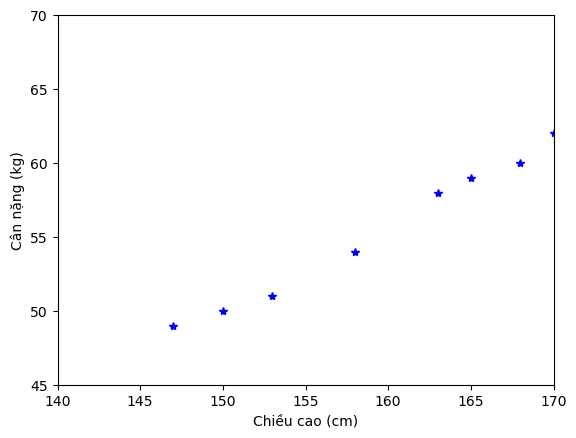

In [4]:
# Nhập dữ liệu và vẽ scatter plot

# Chiều cao (cm)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T # từ 1 hàng 13 cột, chuyển vị thành 13 hàng 1 cột

# Cân nặng (kg) 
Y =  np.array([[49, 50, 51, 54, 58, 59, 60,62, 63, 64, 66, 67, 68]]).T # Từ 1 hàng 13 cột, chuyển vị thành 13 hàng 1 cột

# Trực quan hóa dữ liệu
plt.plot(X, Y,  'b*') # Vẽ scatter plot với màu xanh dương và ký hiệu *
plt.axis([140, 170, 45, 70]) # Giới hạn trục x từ 140 đến 170 và trục y từ 45 đến 70
plt.xlabel('Chiều cao (cm)') # Nhãn trục x
plt.ylabel('Cân nặng (kg)') # Nhãn trục y
plt.show() # Hiển thị đồ thị

### Vì sao X, Y phải chuyển vị 
Vì dữ liệu đề bài là bảng dữ liệu chiều cao, cân nặng của 13 người
Nếu ko chuyển vị thì Numpy được hiểu là 1 hàng 13 cột tức 1 người có 13 số liệu chứ ko phải số liệu của 13 người vì
### Quy ước chuẩn trong Machine Learning
Trong hầu hết các bài toán ML (và cả trong công thức toán học), dữ liệu được biểu diễn theo quy ước:
$$x \in \mathbb{R}^{n \times d}$$
n = số lượng điểm dữ liệu (số mẫu, ở đây là 13 hoặc 15 người) 
d = số đặc trưng (feature) của mỗi điểm (ở đây d=1, chỉ có chiều cao) 

Trước khi .T:  1 hàng, 13 cột  → "1 người, 13 đặc điểm" (SAI ý)  
Sau khi .T:    13 hàng, 1 cột  → "13 người, mỗi người 1 đặc điểm" (ĐÚNG ý)

Mô hình hồi quy tuyến tính có dạng: y = w₀ + w₁·x   
    w₀ là hệ số chặn/bias  
    w₁ là hệ số góc/slope  
Để tính cả w₀ và w₁ cùng lúc bằng phép nhân ma trận, người ta "độn" thêm 1 cột toàn số 1 vào trước cột X, gọi là Xbar. Khi đó công thức trở thành: y ≈ Xbar · w, với w = [w₀, w₁]ᵀ.   
Ví dụ nếu X = [147, 150, ...] thì Xbar sẽ là:  
[[1, 147],   
   [1, 150],   
   [1, 153],   
   ...]  
 ### .T (chuyển vị) ≠ pinv() (nghịch đảo)
.T (transpose): chỉ là xoay hàng thành cột, đổi vị trí phần tử. Không liên quan gì đến việc "giải ngược" phương trình.  
pinv() (nghịch đảo/giả nghịch đảo): tìm ma trận A⁻¹ sao cho A⁻¹ · A = I (ma trận đơn vị). Đây là phép toán để "chia" cho ma trận, giống như số nghịch đảo 1/x trong đại số thường.


w =  [[-33.73541021]
 [  0.55920496]]


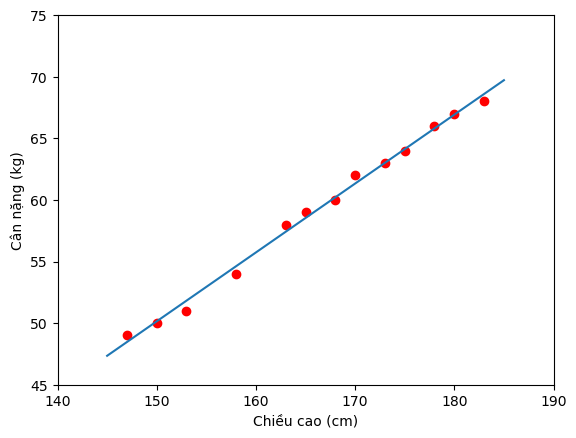

In [9]:
# Tính nghiệm bằng công thức toán học, Xây dựng Xbar
one =  np.ones((X.shape[0], 1)) # Tạo ma trận cột gồm toàn số 1, có cùng số hàng với X
Xbar = np.concatenate((one, X), axis = 1) # Nối ma trận cột one và X theo chiều ngang (axis=1)

# Tính trọng số ccuar đường thẳng khớp (fitting line)
A = np.dot(Xbar.T, Xbar) # Tính tích ma trận của Xbar chuyển vị và Xbar
b = np.dot(Xbar.T, Y) # Tính tích ma trận của Xbar chuyển vị và Y
w = np.dot(np.linalg.pinv(A), b) # Tính trọng số w bằng cách nhân ma trận nghịch đảo của A với b
print('w = ', w) # In ra trọng số w

# Chuẩn bị đường thẳng khớp
w_0 = w[0][0] # Hệ số chặn (intercept)
w_1 = w[1][0] # Hệ số góc (slope)
x0 = np.linspace(145, 185, 2, endpoint=True) # Tạo một mảng x0 gồm 2 giá trị từ 145 đến 185
y0 = w_0 + w_1 * x0 # Tính giá trị y0 tương ứng với x0 theo phương trình đường thẳng

# Vẽ đường thẳng khớp với dữ liệu
plt.plot(X.T, Y.T, 'ro') # Vẽ scatter plot với màu đỏ và ký hiệu o
plt.plot(x0, y0) # đường thẳng khớp
plt.axis([140, 190, 45, 75]) # Giới hạn trục x từ 140 đến 190 và trục y từ 45 đến 75
plt.xlabel('Chiều cao (cm)') # Nhãn trục x
plt.ylabel('Cân nặng (kg)') # Nhãn trục y
plt.show() # Hiển thị đồ thị

In [10]:
y1 = w_1*155 + w_0 # Tính giá trị dự đoán cân nặng cho chiều cao 155 cm
y2 = w_1*160 + w_0 # Tính giá trị dự đoán cân nặng cho chiều cao 160 cm
print('Dự đoán cân nặng cho người có chiều cao 155 cm là: %.2f kg, số liệu thật 52 (kg)' %(y1)) # In ra dự đoán cân nặng cho chiều cao 155 cm
print('Dự đoán cân nặng cho người có chiều cao 160 cm là: %2.f kg, số liệu thật 56 (kg)' %(y2)) # In ra dự đoán cân nặng cho chiều cao 160 cm

Dự đoán cân nặng cho người có chiều cao 155 cm là: 52.94 kg, số liệu thật 52 (kg)
Dự đoán cân nặng cho người có chiều cao 160 cm là: 56 kg, số liệu thật 56 (kg)


In [12]:
# Kiểm tra lại bằng scikit-learn
from sklearn import datasets, linear_model

# Khớp mô hình bằng hồi quy tuyến tính (linear Regression)
regr = linear_model.LinearRegression(fit_intercept=False) # Tạo đối tượng hồi quy tuyến tính, không tính hệ số chặn
# fit_intercept = False để tính hệ số chặn (bias)
regr.fit(Xbar, Y) # Khớp mô hình với dữ liệu Xbar và Y
# So sánh hai kết quả
print('Nghiệm tìm được bằng scikit-learn :', regr.coef_) # In ra trọng số tìm được bằng scikit-learn
print('Nghiệm tìm được từ phương trình:', w.T) # In ra trọng số tìm được từ phương trình


Nghiệm tìm được bằng scikit-learn : [[-33.73541021   0.55920496]]
Nghiệm tìm được từ phương trình: [[-33.73541021   0.55920496]]


w =  [[-62.39341708]
 [  0.7371474 ]]


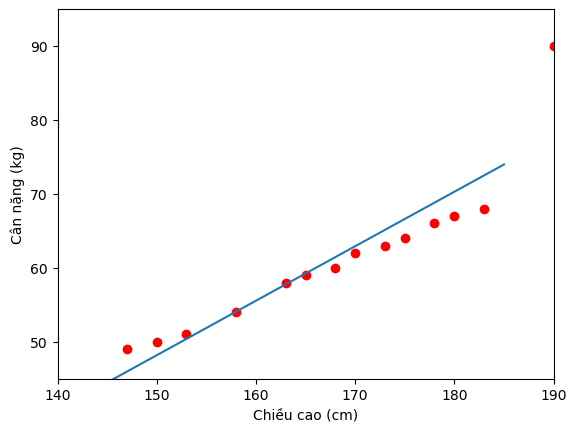

In [5]:
import numpy as np
import matplotlib.pyplot as plt 

# chiều cao (cm)
X= np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183, 190]]).T # từ 1 hàng 14 cột, chuyển vị thành 14 hàng 1 cột
# cân nặng (kg)
Y = np.array([[49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68, 90]]).T # từ 1 hàng 14 cột, chuyển vị thành 14 hàng 1 cột

# Xây dựng hàm Xbar
one = np.ones((X.shape[0],1)) # tạo ma trận cột gồm toàn số 1, có cùng số hàng với X
xbar = np.concatenate((one, X), axis = 1) # nối ma trận cột one và X theo chiều ngang (axis=1)

# Tính trọng số của đường thẳng khớp (fitting line)
A =  np.dot(xbar.T, xbar) # tính tích ma trận của xbar chuyển vị và xbar
b = np.dot(xbar.T, Y) # tính tích ma trận của xbar chuyển vị và Y#
w =  np.dot(np.linalg.pinv(A), b) # tính trọng số w bằng cách nhân ma trận nghịch đảo của A với b
print('w = ', w) # in ra trọng số w

# Chuẩn bị đường thẳng khớp
w_0 = w[0][0] # hệ số chặn (intercept)
w_1 = w[1][0] # hệ số góc (slope)
x0 = np.linspace(145, 185, 2, endpoint =  True) # tạo một mảng x0 gồm 2 giá trị từ 145 đến 185
y0 = w_0 + w_1*x0 # tính giá trị y0 tương ứng với x0 theo phương trình đường thẳng

# Vẽ đường thẳng khớp
plt.plot(X, Y, 'ro') # vẽ scatter plot với màu đỏ và ký hiệu o
plt.plot(x0, y0) # đường thẳng khớp
plt.axis([140, 190, 45, 95]) # giới hạn trục x từ 140 đến 190 và trục y từ 45 đến 95
plt.xlabel('Chiều cao (cm)') # nhãn trục x
plt.ylabel('Cân nặng (kg)') # nhãn trục y
plt.show() # hiển thị đồ thị